# Etapa 1 — Reto *Cats&Dogs*: de descriptores clásicos a aprendizaje profundo
**Curso:** Visión por Computador Avanzada (PCJIC, 2026-2) · **Autor:** Milton Alvarado

**Base de clase (notebook `Cats&Dogs.ipynb`):** Dataset500 (500 gatos + 500 perros); partición 80/20 estratificada con `random_state=77`;
SVC con búsqueda en malla del kernel (`cv=2`). Imagen aplanada 150×150×3 = 67 500 características → **58 % de exactitud en prueba** (CV 0.60);
HOG global sobre gris 128×128 (9 orientaciones, celdas 8×8, bloques 2×2 → 8 100 características) → **73 % de exactitud en validación cruzada** (kernel `poly`).

> **Ojo con la comparación.** El 58 % es exactitud sobre el conjunto de *prueba*, pero el 73 % que reporta la clase es la exactitud media de *validación cruzada* sobre el
> conjunto de entrenamiento (el notebook no imprime la exactitud en prueba de HOG). Por eso este cuaderno **re-ejecuta ambas líneas base con la misma partición** y reporta
> siempre las dos métricas: `acc` (prueba) y `cv2` (validación cruzada de 2 pliegues sobre entrenamiento, igual que la clase).

**Objetivo:** (b) ≥ 2 resultados nuevos con ML clásico, (c) superar la línea base con aprendizaje profundo, (d) analizar con fundamentos matemáticos.

**Conexión con la tesis (DoE para VI-SLAM):** cada modificación es un *factor* con niveles explícitos (descriptor, celdas HOG, C, profundidad de la CNN) registrado en una tabla de corridas con semilla fija.

## 0. Configuración y descarga de datos

In [5]:
# Dataset reducido de la clase (1000 imágenes). Para Drive: comenta las dos líneas siguientes y ajusta BASE.
!wget -q -nc https://github.com/rubenchov/aprendizajeautomaticovision/releases/download/v1.0.0/Dataset500.zip -O /content/Dataset500.zip
!unzip -q -n /content/Dataset500.zip -d /content/ds

Datos en: /content/ds/Dataset500
1000 imágenes: {'Cat': np.int64(500), 'Dog': np.int64(500)}
train/test: 800 200


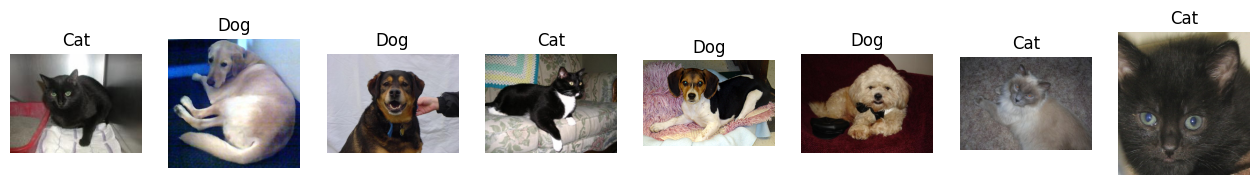

In [6]:
import os, time, random, warnings, itertools
import numpy as np, pandas as pd, matplotlib.pyplot as plt, cv2
from pathlib import Path
warnings.filterwarnings("ignore")

SEED = 42            # semilla de modelos
SPLIT_SEED = 77      # misma partición que el notebook de clase
random.seed(SEED); np.random.seed(SEED)

BASE = Path("/content/ds")          # AJUSTAR si usas Drive o el dataset completo de Kaggle
def find_root(base):
    for p in [base] + sorted(base.rglob("*")):
        if p.is_dir() and {"Cat","Dog"} <= {d.name for d in p.iterdir() if d.is_dir()}: return p
    raise FileNotFoundError("No se encontró una carpeta con subcarpetas Cat/ y Dog/")
DATA_DIR = find_root(BASE); print("Datos en:", DATA_DIR)

Categories = ['Cat','Dog']
paths, labels = [], []
for i, c in enumerate(Categories):
    for f in sorted(os.listdir(DATA_DIR/c)):
        if f.lower().endswith(('.jpg','.jpeg','.png')):
            paths.append(str(DATA_DIR/c/f)); labels.append(i)
paths, labels = np.array(paths), np.array(labels)
print(len(paths), "imágenes:", dict(zip(Categories, np.bincount(labels))))

from sklearn.model_selection import train_test_split
p_tr, p_te, ytr, yte = train_test_split(paths, labels, test_size=0.20, random_state=SPLIT_SEED, stratify=labels)
print("train/test:", len(p_tr), len(p_te))

fig, ax = plt.subplots(1, 8, figsize=(16, 2.2))
for a, i in zip(ax, np.random.RandomState(SEED).choice(len(p_tr), 8, replace=False)):
    a.imshow(cv2.cvtColor(cv2.imread(p_tr[i]), cv2.COLOR_BGR2RGB)); a.set_title(Categories[ytr[i]]); a.axis("off")
plt.show()

## 1. Aprendizaje automático clásico

### 1.1 Fundamentos de los descriptores
* **Imagen aplanada.** $x\in\mathbb R^{150\cdot150\cdot3}$: cada píxel es una característica. Con $n=800$ muestras de entrenamiento y $D=67\,500$ se está en el régimen $D\gg n$ (maldición de la dimensionalidad): las distancias euclídeas se concentran y quedan dominadas por brillo y posición, no por la forma del animal.
* **HOG.** Gradiente $\nabla I=(G_x,G_y)$, magnitud $m=\sqrt{G_x^2+G_y^2}$, orientación $\theta=\arctan(G_y/G_x)$. Cada celda ($p\times p$) acumula un histograma de $B$ orientaciones ponderado por $m$; los bloques se normalizan (L2-Hys). Dimensión:
  $D=\big(\tfrac{H}{p}-b+1\big)\big(\tfrac{W}{p}-b+1\big)b^2B$. Con $H=W=128,\,p=8,\,b=2,\,B=9$: $15\cdot15\cdot36=8100$ (coincide con la clase).
* **LBP.** $\mathrm{LBP}_{P,R}=\sum_{k=0}^{P-1}s(g_k-g_c)2^k$: textura local, invariante a cambios monótonos de brillo.
* **Histograma HSV.** Distribución de color; complementa a HOG/LBP (pelaje).
* **SVM RBF/poly.** Maximiza el margen $2/\|w\|$; $K_{rbf}=e^{-\gamma\|x-x'\|^2}$, $K_{poly}=(\gamma\langle x,x'\rangle+r)^d$. $C$ controla el compromiso sesgo–varianza.
* **PCA.** Proyecta sobre los autovectores de la covarianza que retienen 95 % de la varianza: reduce ruido y coste.
* **Ensamble (soft voting).** $\hat y=\arg\max_k\sum_m w_mP_m(k\mid x)$.

In [7]:
from skimage.feature import hog, local_binary_pattern

def rd_rgb(p, s): return cv2.resize(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB), (s, s), interpolation=cv2.INTER_AREA)
def rd_gray(p, s): return cv2.resize(cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2GRAY), (s, s), interpolation=cv2.INTER_AREA)

def d_flat(P):   return np.array([rd_rgb(p,150).ravel()/255. for p in P], dtype=np.float32)          # 67 500 (como la clase)
def d_hog(P, ppc=8, orient=9, cpb=2):                                                                # 8 100 con los valores por defecto
    return np.array([hog(rd_gray(p,128), orientations=orient, pixels_per_cell=(ppc,ppc), cells_per_block=(cpb,cpb),
                         block_norm="L2-Hys") for p in P])
def d_lbp(P, Pn=8, R=1, grid=4):
    out=[]
    for p in P:
        g = rd_gray(p,128); l = local_binary_pattern(g, Pn, R, "uniform"); h = g.shape[0]//grid; f=[]
        for i in range(grid):
            for j in range(grid):
                hist,_ = np.histogram(l[i*h:(i+1)*h, j*h:(j+1)*h], bins=Pn+2, range=(0,Pn+2)); f.append(hist/max(hist.sum(),1))
        out.append(np.concatenate(f))
    return np.array(out)
def d_hsv(P, bins=(8,8,8)):
    out=[]
    for p in P:
        h = cv2.calcHist([cv2.cvtColor(rd_rgb(p,128), cv2.COLOR_RGB2HSV)],[0,1,2],None,bins,[0,180,0,256,0,256])
        out.append(cv2.normalize(h,h).flatten())
    return np.array(out)

t=time.time(); F = {}
for name, fn in {"flat":d_flat,"hog":d_hog,"lbp":d_lbp,"hsv":d_hsv}.items():
    F[name] = (fn(p_tr), fn(p_te)); print(name, F[name][0].shape, f"{time.time()-t:.0f}s")
F["hog+lbp+hsv"] = tuple(np.hstack([F[k][s] for k in ("hog","lbp","hsv")]) for s in (0,1))

flat (800, 67500) 6s
hog (800, 8100) 25s
lbp (800, 160) 33s
hsv (800, 512) 35s


### 1.2 Líneas base replicadas y nuevos modelos
`acc` = exactitud en prueba; `cv2` = exactitud de validación cruzada de 2 pliegues en entrenamiento (la métrica que usó la clase para HOG).

In [8]:
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

runs = []
def run(tag, desc, model):
    Ftr, Fte = F[desc]; t=time.time(); model.fit(Ftr, ytr); p = model.predict(Fte)
    cv2s = model.best_score_ if hasattr(model, "best_score_") else cross_val_score(clone(model), Ftr, ytr, cv=2, n_jobs=-1).mean()
    r = dict(tag=tag, descriptor=desc, acc=accuracy_score(yte,p), f1=f1_score(yte,p,average="macro"), cv2=cv2s, seconds=round(time.time()-t,1))
    runs.append(r); print({k:(round(v,3) if isinstance(v,float) else v) for k,v in r.items()}); return model, p

grid = {"kernel": ["rbf","linear","poly"]}
# --- Líneas base (idénticas a la clase: SVC + GridSearchCV(cv=2) sobre el kernel)
run("base_flat_SVC", "flat", GridSearchCV(SVC(), grid, cv=2, n_jobs=-1))
run("base_HOG_SVC",  "hog",  GridSearchCV(SVC(), grid, cv=2, n_jobs=-1))
# --- Nuevos resultados (b)
run("N1_HOG_scaled_PCA_SVM", "hog",  make_pipeline(StandardScaler(), PCA(0.95, random_state=SEED), SVC(C=10, gamma="scale", random_state=SEED)))
run("N2_LBP_SVM",            "lbp",  make_pipeline(StandardScaler(), SVC(C=10, random_state=SEED)))
run("N3_HOG+LBP+HSV_SVM",    "hog+lbp+hsv", make_pipeline(StandardScaler(), PCA(0.95, random_state=SEED), SVC(C=10, random_state=SEED)))
run("N4_HOG+LBP+HSV_HGB",    "hog+lbp+hsv", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=SEED))

{'tag': 'base_flat_SVC', 'descriptor': 'flat', 'acc': 0.605, 'f1': 0.605, 'cv2': np.float64(0.586), 'seconds': 178.2}
{'tag': 'base_HOG_SVC', 'descriptor': 'hog', 'acc': 0.685, 'f1': 0.685, 'cv2': np.float64(0.734), 'seconds': 11.8}
{'tag': 'N1_HOG_scaled_PCA_SVM', 'descriptor': 'hog', 'acc': 0.705, 'f1': 0.702, 'cv2': np.float64(0.712), 'seconds': 4.0}
{'tag': 'N2_LBP_SVM', 'descriptor': 'lbp', 'acc': 0.705, 'f1': 0.705, 'cv2': np.float64(0.684), 'seconds': 0.2}
{'tag': 'N3_HOG+LBP+HSV_SVM', 'descriptor': 'hog+lbp+hsv', 'acc': 0.72, 'f1': 0.72, 'cv2': np.float64(0.732), 'seconds': 4.5}
{'tag': 'N4_HOG+LBP+HSV_HGB', 'descriptor': 'hog+lbp+hsv', 'acc': 0.66, 'f1': 0.659, 'cv2': np.float64(0.735), 'seconds': 451.1}


(HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                                random_state=42),
 array([1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
        1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
        0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
        0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        0, 1]))

In [9]:
# N5: ensamble soft-voting sobre el descriptor concatenado
ens = VotingClassifier([
    ("svm", make_pipeline(StandardScaler(), PCA(0.95, random_state=SEED), SVC(C=10, probability=True, random_state=SEED))),
    ("lr",  make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=2000))),
    ("rf",  RandomForestClassifier(400, n_jobs=-1, random_state=SEED)),
], voting="soft")
ens_model, ens_pred = run("N5_ensemble_soft", "hog+lbp+hsv", ens)

{'tag': 'N5_ensemble_soft', 'descriptor': 'hog+lbp+hsv', 'acc': 0.72, 'f1': 0.72, 'cv2': np.float64(0.734), 'seconds': 40.0}


### 1.3 Barrido de hiperparámetros de HOG y SVM (mini-DoE factorial 3×3×3)
En lugar de variar un factor a la vez (OFAT), se evalúa el factorial completo
$p\in\{6,8,12\}\times B\in\{6,9,12\}\times C\in\{1,10,100\}$ (27 corridas) con validación cruzada de 3 pliegues **solo sobre el entrenamiento** (sin tocar la prueba) y se ajusta un modelo cuadrático de la exactitud (RSM):
$\hat y=\beta_0+\sum\beta_ix_i+\sum\beta_{ii}x_i^2+\sum_{i<j}\beta_{ij}x_ix_j$.

In [10]:
rows=[]
for ppc, orient, C in itertools.product([6,8,12],[6,9,12],[1,10,100]):
    Fh = d_hog(p_tr, ppc, orient)
    s = cross_val_score(make_pipeline(StandardScaler(), SVC(C=C)), Fh, ytr, cv=3, n_jobs=-1).mean()
    rows.append(dict(ppc=ppc, orient=orient, logC=np.log10(C), acc=s))
doe = pd.DataFrame(rows); display(doe.sort_values("acc", ascending=False).head(8))

import statsmodels.formula.api as smf
m = smf.ols("acc ~ ppc + orient + logC + I(ppc**2) + I(orient**2) + I(logC**2) + ppc:orient + ppc:logC + orient:logC", doe).fit()
print(m.summary().tables[1]); print("R2 =", round(m.rsquared,3))

,ppc,orient,logC,acc
17,8,12,2.0,0.744985
16,8,12,1.0,0.744985
8,6,12,2.0,0.741249
7,6,12,1.0,0.741249
12,8,9,0.0,0.741240
11,8,6,2.0,0.740005
10,8,6,1.0,0.740005
15,8,12,0.0,0.739996


                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.6960      0.021     33.288      0.000       0.652       0.740
ppc                0.0187      0.003      5.395      0.000       0.011       0.026
orient            -0.0094      0.003     -3.096      0.007      -0.016      -0.003
logC               0.0037      0.005      0.734      0.473      -0.007       0.014
I(ppc ** 2)       -0.0011      0.000     -5.928      0.000      -0.001      -0.001
I(orient ** 2)     0.0005      0.000      3.336      0.004       0.000       0.001
I(logC ** 2)      -0.0015      0.001     -1.073      0.298      -0.005       0.001
ppc:orient      -1.89e-05      0.000     -0.173      0.865      -0.000       0.000
ppc:logC          -0.0006      0.000     -1.791      0.091      -0.001       0.000
orient:logC        0.0007      0.000      1.971      0.065   -4.64e-05       0.001
R2 =

## 2. Aprendizaje profundo

> **Advertencia sobre el tamaño del conjunto.** Con Dataset500 solo hay 800 imágenes de entrenamiento (≈680 tras separar validación): una CNN entrenada desde cero tiende a sobreajustar.
> Es un resultado esperable y digno de análisis; la transferencia de aprendizaje (MobileNetV2) es la opción natural. Si tienes el dataset completo de Kaggle (25 000 imágenes), cambia `BASE` y compara cómo crece la CNN desde cero con más datos.

### 2.1 Fundamentos
* **Convolución.** $y_{i,j,k}=\sigma\big(b_k+\sum_{c}\sum_{u,v}w_{u,v,c,k}\,x_{i+u,j+v,c}\big)$; una capa $3\times3$ con $C_{in}\to C_{out}$ tiene $9C_{in}C_{out}+C_{out}$ parámetros, independientes del tamaño de imagen.
* **Sigmoide + entropía cruzada binaria.** $\mathcal L=-[y\log p+(1-y)\log(1-p)]$, gradiente respecto al logit $=p-y$.
* **BatchNorm, Dropout, aumento de datos**: regularizadores (escala estable de activaciones, ensamble implícito, invariancias).
* **Transferencia (MobileNetV2/ImageNet).** Los primeros filtros (bordes, texturas) son genéricos; solo se entrena la cabeza, lo que reduce el sobreajuste con pocas imágenes.
* **Autoencoder convolucional.** $\min\|x-g_\phi(f_\theta(x))\|^2$; el codificador congelado es un extractor no supervisado.

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.keras.utils.set_random_seed(SEED)
print(tf.__version__, tf.config.list_physical_devices("GPU"))

DL_SIZE = 128
def load_imgs(P): return np.array([rd_rgb(p, DL_SIZE) for p in P], dtype=np.uint8)
Xtr_all = load_imgs(p_tr); Xte_d = load_imgs(p_te); yte_d = yte
Xtr_d, Xva_d, ytr_d, yva_d = train_test_split(Xtr_all, ytr, test_size=0.15, stratify=ytr, random_state=SEED)
print(Xtr_d.shape, Xva_d.shape, Xte_d.shape)          # la prueba es la MISMA que en ML clásico

aug = keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.08), layers.RandomZoom(0.1)])
def cnn(depth=3, filters=32, dropout=0.4, bn=True, use_aug=True):
    inp = keras.Input((DL_SIZE, DL_SIZE, 3)); x = layers.Rescaling(1/255.)(inp)
    if use_aug: x = aug(x)
    for d in range(depth):
        x = layers.Conv2D(filters*2**d, 3, padding="same", use_bias=not bn)(x)
        if bn: x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x); x = layers.MaxPool2D()(x)
    x = layers.GlobalAveragePooling2D()(x); x = layers.Dropout(dropout)(x)
    return keras.Model(inp, layers.Dense(1, activation="sigmoid")(x))

dl_runs=[]; dl_pred={}
def fit_eval(tag, model, epochs=40, lr=1e-3):
    model.compile(keras.optimizers.Adam(lr), loss="binary_crossentropy", metrics=["accuracy"])
    h = model.fit(Xtr_d, ytr_d, validation_data=(Xva_d, yva_d), epochs=epochs, batch_size=32, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
                   keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)])
    p = (model.predict(Xte_d, verbose=0).ravel() > 0.5).astype(int); dl_pred[tag] = p
    r = dict(tag=tag, params=model.count_params(), acc=accuracy_score(yte_d,p), f1=f1_score(yte_d,p,average="macro"),
             best_val_acc=max(h.history["val_accuracy"]), epochs=len(h.history["loss"]))
    dl_runs.append(r); print(r); return model, h, p

2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
(680, 128, 128, 3) (120, 128, 128, 3) (200, 128, 128, 3)


In [14]:
# D1-D3: profundidad de la CNN secuencial (factor: depth)
for d in (2, 3, 4):
    fit_eval(f"D_CNN_depth{d}", cnn(depth=d))

{'tag': 'D_CNN_depth2', 'params': 19745, 'acc': 0.5, 'f1': 0.3333333333333333, 'best_val_acc': 0.5, 'epochs': 9}
{'tag': 'D_CNN_depth3', 'params': 94049, 'acc': 0.5, 'f1': 0.3333333333333333, 'best_val_acc': 0.5, 'epochs': 9}


{'tag': 'D_CNN_depth4', 'params': 390113, 'acc': 0.5, 'f1': 0.3333333333333333, 'best_val_acc': 0.5, 'epochs': 9}


In [15]:
# D4: transferencia con MobileNetV2 congelada
base = keras.applications.MobileNetV2(input_shape=(DL_SIZE,DL_SIZE,3), include_top=False, weights="imagenet"); base.trainable=False
inp = keras.Input((DL_SIZE,DL_SIZE,3)); x = aug(inp); x = keras.applications.mobilenet_v2.preprocess_input(x)
x = layers.GlobalAveragePooling2D()(base(x, training=False)); x = layers.Dropout(0.3)(x)
tl = keras.Model(inp, layers.Dense(1, activation="sigmoid")(x))
tl, h_tl, p_tl = fit_eval("D4_MobileNetV2_frozen", tl, epochs=20)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


{'tag': 'D4_MobileNetV2_frozen', 'params': 2259265, 'acc': 0.945, 'f1': 0.9449656035021888, 'best_val_acc': 0.9916666746139526, 'epochs': 20}


In [16]:
# D5: autoencoder convolucional -> codificador congelado + clasificador
inp = keras.Input((DL_SIZE,DL_SIZE,3)); x = layers.Rescaling(1/255.)(inp)
for f in (32,64,128): x = layers.Conv2D(f,3,strides=2,padding="same",activation="relu")(x)
z = layers.Conv2D(64,3,padding="same",activation="relu")(x)
y_ = z
for f in (128,64,32): y_ = layers.Conv2DTranspose(f,3,strides=2,padding="same",activation="relu")(y_)
rec = layers.Conv2D(3,3,padding="same",activation="sigmoid")(y_)
ae = keras.Model(inp, rec); ae.compile("adam","mse")
ae.fit(Xtr_d, Xtr_d/255., epochs=40, batch_size=32, verbose=0, validation_data=(Xva_d, Xva_d/255.))
enc = keras.Model(inp, z); enc.trainable=False
inp2 = keras.Input((DL_SIZE,DL_SIZE,3)); h = layers.GlobalAveragePooling2D()(enc(inp2))
ae_clf = keras.Model(inp2, layers.Dense(1, activation="sigmoid")(layers.Dropout(0.3)(h)))
ae_clf, h_ae, p_ae = fit_eval("D5_AE_encoder+head", ae_clf, epochs=30)

{'tag': 'D5_AE_encoder+head', 'params': 167105, 'acc': 0.505, 'f1': 0.5034980816971338, 'best_val_acc': 0.550000011920929, 'epochs': 12}


{'tag': 'D_CNN_depth2', 'params': 19745, 'acc': 0.58, 'f1': 0.5798319327731092, 'best_val_acc': 0.6833333373069763, 'epochs': 27}
{'tag': 'D_CNN_depth3', 'params': 94049, 'acc': 0.635, 'f1': 0.6323436831104732, 'best_val_acc': 0.75, 'epochs': 40}
{'tag': 'D_CNN_depth4', 'params': 390113, 'acc': 0.725, 'f1': 0.7219343259435274, 'best_val_acc': 0.7250000238418579, 'epochs': 42}
{'tag': 'D_CNN_depth3_noBN', 'params': 93377, 'acc': 0.625, 'f1': 0.6245400615754299, 'best_val_acc': 0.699999988079071, 'epochs': 41}


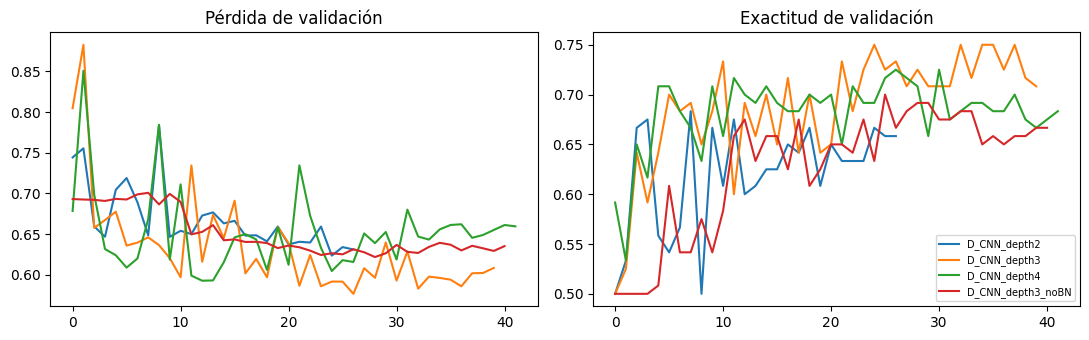

In [20]:
# Re-ejecución de las CNN desde cero: BatchNorm con momentum 0.9 y early stopping más paciente
dl_runs = [r for r in dl_runs if not r["tag"].startswith("D_CNN")]
hist = {}

def cnn(depth=3, filters=32, dropout=0.4, bn=True, use_aug=True):
    inp = keras.Input((DL_SIZE, DL_SIZE, 3)); x = layers.Rescaling(1/255.)(inp)
    if use_aug: x = aug(x)
    for d in range(depth):
        x = layers.Conv2D(filters*2**d, 3, padding="same", use_bias=not bn)(x)
        if bn: x = layers.BatchNormalization(momentum=0.9)(x)
        x = layers.ReLU()(x); x = layers.MaxPool2D()(x)
    x = layers.GlobalAveragePooling2D()(x); x = layers.Dropout(dropout)(x)
    return keras.Model(inp, layers.Dense(1, activation="sigmoid")(x))

def fit_cnn(tag, model, epochs=80, lr=1e-3):
    model.compile(keras.optimizers.Adam(lr), loss="binary_crossentropy", metrics=["accuracy"])
    h = model.fit(Xtr_d, ytr_d, validation_data=(Xva_d, yva_d), epochs=epochs, batch_size=32, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15, start_from_epoch=10, restore_best_weights=True),
                   keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5)])
    p = (model.predict(Xte_d, verbose=0).ravel() > 0.5).astype(int); dl_pred[tag] = p; hist[tag] = h.history
    r = dict(tag=tag, params=model.count_params(), acc=accuracy_score(yte_d, p), f1=f1_score(yte_d, p, average="macro"),
             best_val_acc=max(h.history["val_accuracy"]), epochs=len(h.history["loss"]))
    dl_runs.append(r); print(r)

for d in (2, 3, 4):
    fit_cnn(f"D_CNN_depth{d}", cnn(depth=d))
fit_cnn("D_CNN_depth3_noBN", cnn(depth=3, bn=False))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for t, h in hist.items():
    ax[0].plot(h["val_loss"], label=t); ax[1].plot(h["val_accuracy"], label=t)
ax[0].set_title("Pérdida de validación"); ax[1].set_title("Exactitud de validación"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig("curvas_cnn_etapa1.png", dpi=200); plt.show()

## 3. Resultados y análisis

In [21]:
res = pd.concat([pd.DataFrame(runs).assign(family="ML clásico"), pd.DataFrame(dl_runs).assign(family="Deep learning")])
res = res.sort_values("acc", ascending=False); display(res[["family","tag","acc","f1","cv2"]])
res.to_csv("resultados_etapa1.csv", index=False)
b = res.iloc[0]
print(f"Mejor: {b.tag}  acc={b.acc:.3f}")
print("Referencias de clase -> flat: 0.58 (prueba) | HOG: 0.73 (CV en entrenamiento, no en prueba)")

,family,tag,acc,f1,cv2
0,Deep learning,D4_MobileNetV2_frozen,0.945,0.944966,NaN
4,Deep learning,D_CNN_depth4,0.725,0.721934,NaN
6,ML clásico,N5_ensemble_soft,0.720,0.720000,0.73375
4,ML clásico,N3_HOG+LBP+HSV_SVM,0.720,0.719972,0.73250
3,ML clásico,N2_LBP_SVM,0.705,0.704816,0.68375
2,ML clásico,N1_HOG_scaled_PCA_SVM,0.705,0.702313,0.71250
1,ML clásico,base_HOG_SVC,0.685,0.684992,0.73375
5,ML clásico,N4_HOG+LBP+HSV_HGB,0.660,0.659148,0.73500
3,Deep learning,D_CNN_depth3,0.635,0.632344,NaN
5,Deep learning,D_CNN_depth3_noBN,0.625,0.624540,NaN


Mejor: D4_MobileNetV2_frozen  acc=0.945
Referencias de clase -> flat: 0.58 (prueba) | HOG: 0.73 (CV en entrenamiento, no en prueba)


        ML ok  ML mal
DL ok     138      51
DL mal      6       5
McNemar exacto p = 5.676193126635808e-10


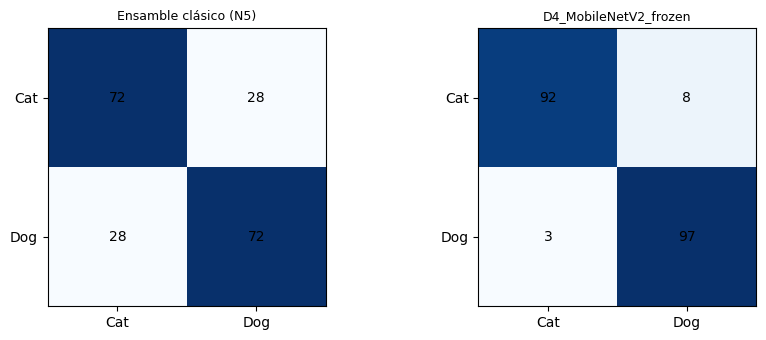

In [22]:
# Matrices de confusión y prueba de McNemar (mejor DL vs mejor ML clásico) -- misma partición de prueba
from statsmodels.stats.contingency_tables import mcnemar
p_ml = ens_pred                                  # ensamble clásico N5 (cámbialo si otro N resulta mejor)
best_dl = max(dl_runs, key=lambda r: r["acc"])["tag"]; p_dl = dl_pred[best_dl]
ok_dl, ok_ml = (p_dl==yte), (p_ml==yte)
tab = [[(ok_dl&ok_ml).sum(), (ok_dl&~ok_ml).sum()], [(~ok_dl&ok_ml).sum(), (~ok_dl&~ok_ml).sum()]]
print(pd.DataFrame(tab, index=["DL ok","DL mal"], columns=["ML ok","ML mal"])); print("McNemar exacto p =", mcnemar(tab, exact=True).pvalue)
fig, ax = plt.subplots(1,2, figsize=(9,3.5))
for a, p, t in zip(ax, (p_ml, p_dl), ("Ensamble clásico (N5)", best_dl)):
    cm = confusion_matrix(yte, p); a.imshow(cm, cmap="Blues"); a.set_title(t, fontsize=9)
    a.set_xticks([0,1]); a.set_yticks([0,1]); a.set_xticklabels(Categories); a.set_yticklabels(Categories)
    for (i,j),v in np.ndenumerate(cm): a.text(j,i,v,ha="center",va="center")
plt.tight_layout(); plt.savefig("cm_etapa1.png", dpi=200); plt.show()

In [23]:
from google.colab import drive
drive.mount('/content/drive')
import shutil
from pathlib import Path
OUT = Path("/content/drive/MyDrive/PhD/2026_02/Vision_por_computador/Ejercicio 2/resultados/etapa1")
OUT.mkdir(parents=True, exist_ok=True)
for f in ["resultados_etapa1.csv", "cm_etapa1.png"]:
    if Path(f).exists(): shutil.copy(f, OUT / f); print("copiado:", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
copiado: resultados_etapa1.csv
copiado: cm_etapa1.png


### 3.1 Guía para redactar el análisis (completar con tus cifras)
1. **Flat vs HOG.** Con $D=67\,500\gg n=800$ el SVM ve casi solo ruido de posición/brillo; HOG (8 100 características) codifica contornos e introduce invariancia a iluminación y pequeñas traslaciones. Recuerda aclarar que 0.73 es CV en entrenamiento y contrastarlo con la exactitud en prueba de `base_HOG_SVC`.
2. **PCA, C, γ y el mini-DoE.** Interpretar varianza retenida y los términos significativos del RSM (interacción $p\times\log C$); comentar que con 800 muestras la CV de 3 pliegues tiene alta varianza (≈ ±3 % por pliegue).
3. **Ensamble.** Comparar la correlación de errores entre SVM/LR/RF; si $\rho\approx1$ el aporte es nulo (fórmula de varianza del ensamble).
4. **DL vs clásico.** Contar parámetros, curvas train/val (sobreajuste de la CNN desde cero con 680 imágenes), efecto de la profundidad y de la transferencia; usar McNemar para decidir si la diferencia es estadísticamente significativa (con 200 imágenes de prueba, 1 imagen = 0.5 %).
5. **Limitaciones.** Un solo split (`random_state=77`); repetir con varias particiones y reportar media ± desviación e IC 95 %.